In [1]:
#Task: Building an Image Classifier using Sequential API.
#Dataset: MNIST Fashion dataset. (70,000 grayscale images of 28x28 pixels, with 10 Classes)

##Task 1: Import all the required libraries##
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)

2.20.0


In [4]:
##Task 2: Successfully load dataset##
##2.1: Use Keras API to load dataset.

from keras.datasets import fashion_mnist
(x_train_full, y_train_full), (x_test, y_test) = fashion_mnist.load_data()

 **CLASS NAMES**

In [6]:
#2.2 Class names (labels) are not included with the dataset; we will store them to use
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
"Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

##Task 3 Exploring the dataset & We are splitting the dataset into Train and Test
##3.1 Check size and shape
print(x_train_full.shape)
print(x_train_full.shape)

print(x_test.shape)
print(y_test.shape)

print(x_train_full.dtype)
print(x_test.dtype)

(60000, 28, 28)
(60000, 28, 28)
(10000, 28, 28)
(10000,)
uint8
uint8


(5000, 28, 28)
(55000, 28, 28)
(10000, 28, 28)
float64
float64
float64


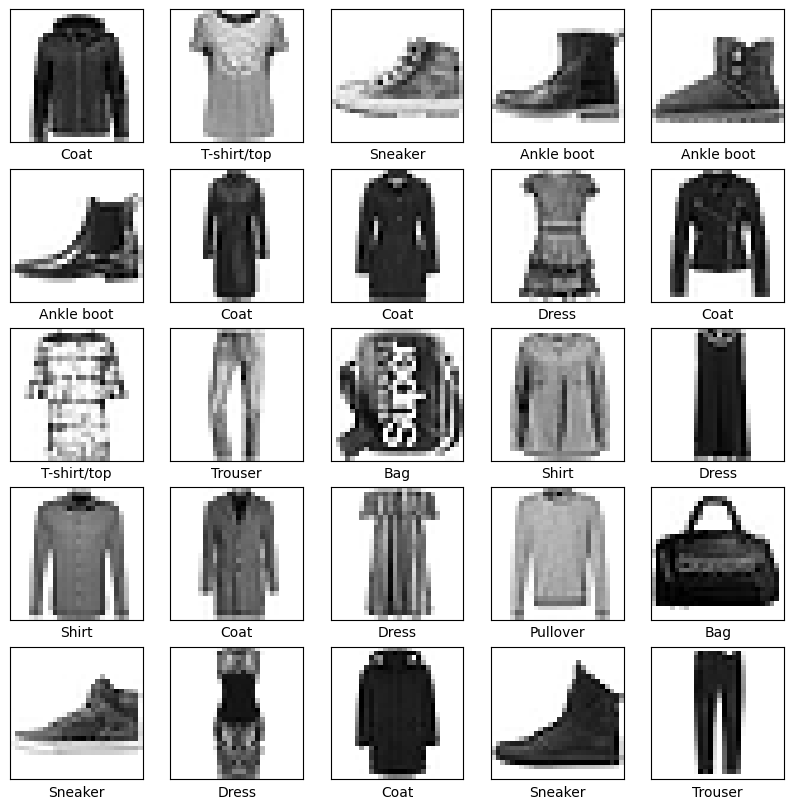

In [7]:

##3.2 Scaling the pixel value 0-255 to the value 0 & 1
x_valid, x_train = x_train_full[:5000] /255.0, x_train_full[5000:] /255.0
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
x_test = x_test /255.0

print(x_valid.shape)
print(x_train.shape)

print(x_test.shape)

print(x_valid.dtype)
print(x_train.dtype)
print(x_test.dtype)


##3.3 Display first 25 images and its names from the training set
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i]])
plt.show()

**NEURAL NETWORK BUILDING**

In [8]:
##Task 4: Build a neural network,
##4.1: Use Keras sequential API to build your model (MLP with 2 hidden layers)
## We are using the activation fucntion named "Rectified Linear unit & Softmax" so that complex data can be trained.

model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=[28, 28]))
model.add(tf.keras.layers.Dense(300, activation="relu"))
model.add(tf.keras.layers.Dense(100, activation="relu"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

###we can use diff

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
###Task 5: Compile and train the model
##5.1  Tweak learned parameters (learning rate, optimizers, loss functions etc)
model.compile(loss="sparse_categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])
##5.2: Train the model with epochs = 50
history = model.fit(x_train, y_train, epochs=50, validation_data=(x_valid, y_valid))



Epoch 1/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7651 - loss: 0.7086 - val_accuracy: 0.8178 - val_loss: 0.5178
Epoch 2/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8316 - loss: 0.4825 - val_accuracy: 0.8514 - val_loss: 0.4443
Epoch 3/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8446 - loss: 0.4397 - val_accuracy: 0.8436 - val_loss: 0.4470
Epoch 4/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8551 - loss: 0.4127 - val_accuracy: 0.8692 - val_loss: 0.3981
Epoch 5/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8625 - loss: 0.3941 - val_accuracy: 0.8608 - val_loss: 0.4025
Epoch 6/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8685 - loss: 0.3766 - val_accuracy: 0.8688 - val_loss: 0.3746
Epoch 7/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8711 - loss: 0.3644 - val_accuracy: 0.8560 - val_loss: 0.4176
Epoch 8/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8759 - loss: 0.3518 - 

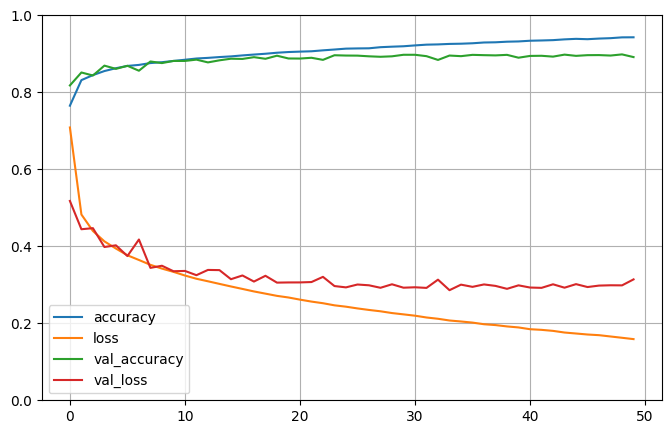

In [10]:
##Task 6: Plot learning curve
import pandas as pd
import matplotlib.pyplot as plt
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

In [11]:
## Task 7 Evaluate the test accuracy
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print('\nTest accuracy:', test_acc)

313/313 - 1s - 4ms/step - accuracy: 0.8803 - loss: 0.3557

Test accuracy: 0.880299985408783


In [12]:
#Task 8  Make prediction on the test dataset
## 8.1 prediction output
probability_model = tf.keras.Sequential([model,
                                         tf.keras.layers.Softmax()])
predictions = probability_model.predict(x_test)
predictions[0]

np.argmax(predictions[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


np.int64(9)

In [13]:
##8.2  Examine with test label (y_test), shows the classification is correct.
y_test[0]

np.uint8(9)